In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from scipy.stats import chi2
import pandas as pd
custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

In [45]:
import rate_exp as re

$$R_{exp} = \mu_{UL}/expousure$$

Primero tenemos que calcular el mu del upper limit que sale de encontrar aquel mu que cumple:

$$0,10 = \sum_{i = 0}^{k_{obs}} P(\mu_{UL}|k_i)$$

Para $k_{obs}$ eventos observados de $n_i$ electrones

In [46]:
eventos = np.array([7,4,0,0,0,0])
expos = np.array([46.61,57.71,63.03,65.56,67.31,68.53])/1000
display(expos)

array([0.04661, 0.05771, 0.06303, 0.06556, 0.06731, 0.06853])

In [47]:
p_on_the_left = 1 - 0.9
degrees_of_freedom = 2 * (eventos + 1)
x = chi2.ppf(1 - p_on_the_left, degrees_of_freedom)
mu_ul = x / 2
print(mu_ul)

[11.77091446  7.99358959  2.30258509  2.30258509  2.30258509  2.30258509]


In [48]:
rates_exp = mu_ul / expos
rates_exp

array([252.54053769, 138.51307548,  36.53157374,  35.12179825,
        34.2086628 ,  33.59966574])

Ahora vamos a suponer que podemos hacer:

$$\varepsilon_{m}^2 = (R_{m}/R_{esp})\cdot \varepsilon_{ref}^2$$

donde: m indica medido, ref indica de referencia y esp es el esperado

In [49]:
df_pb = pd.read_csv('Rates_PB_eps_1e-2_m10-800.csv')
df_md = pd.read_csv('Rates_MD_eps_1e-2_m10-800.csv')


In [50]:
def limites_exclusion(r_exp, df, sigma,ne):
   if ne < 1 or ne > 10:
       raise ValueError("ne debe estar entre 1 y 10")
   if not isinstance(ne, int):
       raise TypeError("ne debe ser un entero")
   if sigma <= 0:
       raise ValueError("La sección eficaz del dataframe debe ser un número positivo")
  
   r_teo = np.array(df[f'{ne}e'])
   sigma_exp = (r_exp/r_teo)*sigma
  
   return sigma_exp  

In [51]:
len(df_pb)

100

In [52]:
eps_pb = np.zeros((len(rates_exp),len(df_pb)))
eps_md = np.zeros((len(rates_exp),len(df_md)))
for i in range(len(rates_exp)):
    eps_pb_ = limites_exclusion(rates_exp[i], df_pb, (1e-2)**2, i+2)
    eps_md_ = limites_exclusion(rates_exp[i], df_md, (1e-2)**2, i+2)
    eps_pb[i, :] = eps_pb_
    eps_md[i, :] = eps_md_

In [53]:
eps_pb[0,:]

array([2.43294594e-12, 2.43235183e-12, 2.44933453e-12, 2.49244199e-12,
       2.49384584e-12, 2.49321806e-12, 2.54320327e-12, 2.60690830e-12,
       2.64764662e-12, 2.68182236e-12, 2.72356094e-12, 2.77026596e-12,
       2.82083080e-12, 2.85054331e-12, 2.87672816e-12, 2.90608615e-12,
       2.95210266e-12, 3.00178823e-12, 3.05468318e-12, 3.09513379e-12,
       3.13857851e-12, 3.18531487e-12, 3.21943837e-12, 3.23786653e-12,
       3.25735656e-12, 3.27798208e-12, 3.30885015e-12, 3.35666112e-12,
       3.40813806e-12, 3.46340153e-12, 3.51415143e-12, 3.56881544e-12,
       3.62780429e-12, 3.69707369e-12, 3.77405611e-12, 3.85802996e-12,
       3.92995847e-12, 3.92903679e-12, 3.92807381e-12, 3.92706770e-12,
       3.92608557e-12, 3.92515357e-12, 3.92417981e-12, 3.92316246e-12,
       3.92221677e-12, 3.92126773e-12, 3.92027617e-12, 3.92732781e-12,
       3.95517164e-12, 3.98470228e-12, 4.01604604e-12, 4.04264242e-12,
       4.07031148e-12, 4.09964201e-12, 4.11892322e-12, 4.11794365e-12,
      

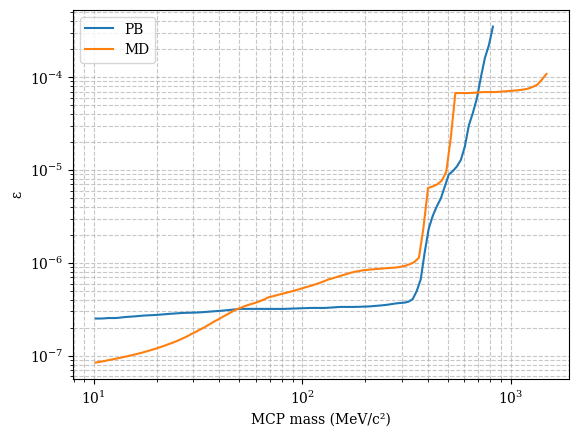

In [54]:
plt.plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[1,:]), label='PB')
plt.plot(df_md[df_md.columns[0]], np.sqrt(eps_md[1,:]), label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('MCP mass (MeV/c²)')
plt.ylabel('ε')
plt.grid(linestyle='--', which='both', alpha=0.7)
plt.legend()

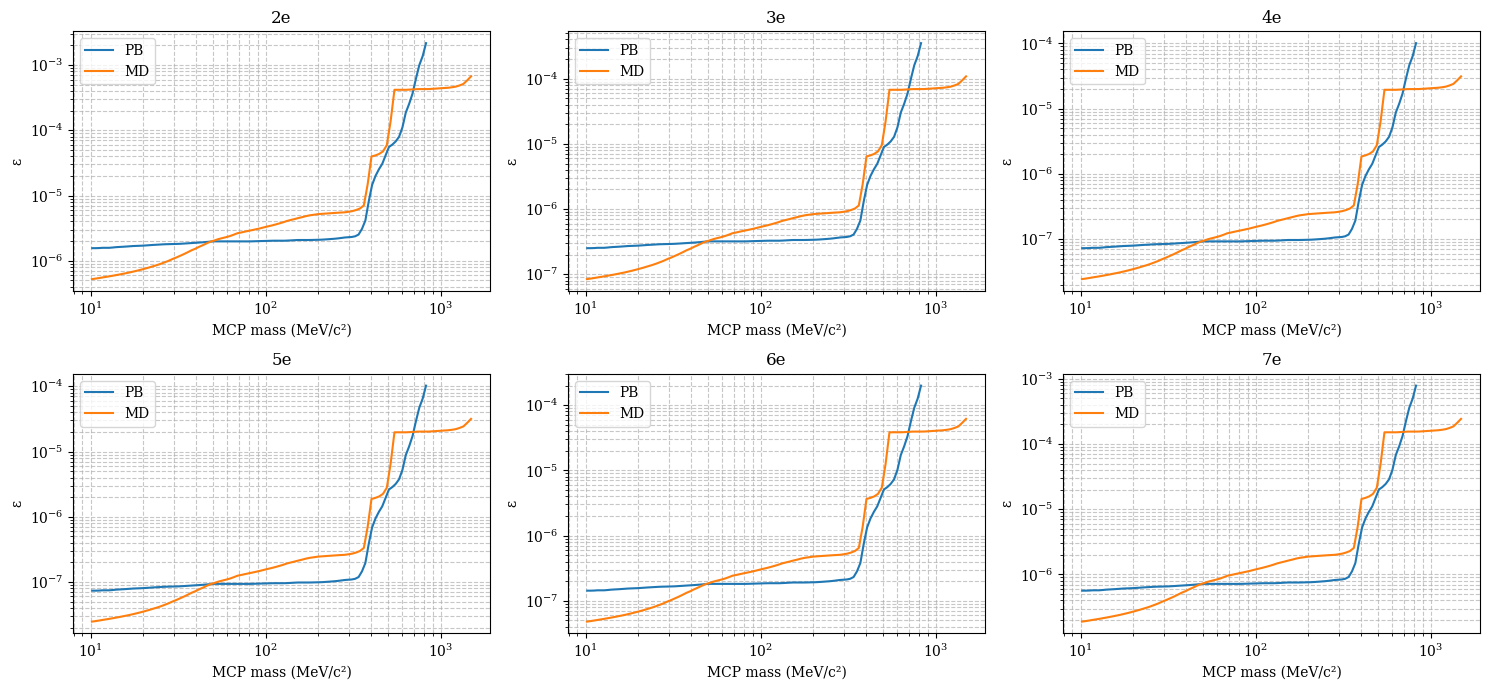

In [55]:
fig, ax = plt.subplots(2,3, figsize=(15, 7))
ax[0,0].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[0,:]), label='PB')
ax[0,0].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[0,:]), label='MD')
ax[0,0].set_title('2e')
ax[0,0].set_xscale('log')
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('MCP mass (MeV/c²)')
ax[0,0].set_ylabel('ε')
ax[0,0].grid(linestyle='--', which='both', alpha=0.7)
ax[0,0].legend()
# 3e
ax[0,1].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[1,:]), label='PB')
ax[0,1].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[1,:]), label='MD')
ax[0,1].set_title('3e')
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xlabel('MCP mass (MeV/c²)')
ax[0,1].set_ylabel('ε')
ax[0,1].grid(linestyle='--', which='both', alpha=0.7)
ax[0,1].legend()
# 4e
ax[0,2].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[2,:]), label='PB')
ax[0,2].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[2,:]), label='MD')
ax[0,2].set_title('4e')
ax[0,2].set_xscale('log')
ax[0,2].set_yscale('log')
ax[0,2].set_xlabel('MCP mass (MeV/c²)')
ax[0,2].set_ylabel('ε')
ax[0,2].grid(linestyle='--', which='both', alpha=0.7)
ax[0,2].legend()
# 5e
ax[1,0].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[3,:]), label='PB')
ax[1,0].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[3,:]), label='MD')
ax[1,0].set_title('5e')
ax[1,0].set_xscale('log')
ax[1,0].set_yscale('log')
ax[1,0].set_xlabel('MCP mass (MeV/c²)')
ax[1,0].set_ylabel('ε')
ax[1,0].grid(linestyle='--', which='both', alpha=0.7)
ax[1,0].legend()
# 6e
ax[1,1].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[4,:]), label='PB')
ax[1,1].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[4,:]), label='MD')
ax[1,1].set_title('6e')
ax[1,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_xlabel('MCP mass (MeV/c²)')
ax[1,1].set_ylabel('ε')
ax[1,1].grid(linestyle='--', which='both', alpha=0.7)
ax[1,1].legend()
# 7e
ax[1,2].plot(df_pb[df_pb.columns[0]], np.sqrt(eps_pb[5,:]), label='PB')
ax[1,2].plot(df_md[df_md.columns[0]], np.sqrt(eps_md[5,:]), label='MD')
ax[1,2].set_title('7e')
ax[1,2].set_xscale('log')
ax[1,2].set_yscale('log')
ax[1,2].set_xlabel('MCP mass (MeV/c²)')
ax[1,2].set_ylabel('ε')
ax[1,2].grid(linestyle='--', which='both', alpha=0.7)
ax[1,2].legend()
plt.tight_layout()
plt.savefig('Limites_mCP_SENSEI.png', dpi=300)